Task 1 — Data Loading, Merging & Deep Exploration:

In [1]:
#Task 1:

# import libraries

import pandas as pd
import numpy as np

# load the csv file

df = pd.read_csv("train.csv")

# check first 5 rows

print(df.head())

# check basic information

print(df.info())

# convert order date and ship date into datetime

df["Order Date"] = pd.to_datetime(df["Order Date"], dayfirst=True)
df["Ship Date"] = pd.to_datetime(df["Ship Date"], dayfirst=True)

# create new time columns

df["Year"] = df["Order Date"].dt.year
df["Month"] = df["Order Date"].dt.month
df["Week Number"] = df["Order Date"].dt.isocalendar().week
df["Day of Week"] = df["Order Date"].dt.day_name()
df["Quarter"] = df["Order Date"].dt.quarter

# create season column

def get_season(month):
    if month in [12, 1, 2]:
        return "Winter"
    elif month in [3, 4, 5]:
        return "Spring"
    elif month in [6, 7, 8]:
        return "Summer"
    else:
        return "Autumn"

df["Season"] = df["Month"].apply(get_season)

# check missing values

print("\nmissing values")
print(df.isnull().sum())

# check duplicate rows

print("\nduplicate rows")
print(df.duplicated().sum())

# check data types

print("\ndata types")
print(df.dtypes)

# create weekly sales

weekly_sales = (
    df.groupby(pd.Grouper(key="Order Date", freq="W"))["Sales"]
    .sum()
    .reset_index()
)

print("\nweekly sales")
print(weekly_sales.head())

# create monthly sales

monthly_sales = (
    df.groupby(pd.Grouper(key="Order Date", freq="M"))["Sales"]
    .sum()
    .reset_index()
)

print("\nmonthly sales")
print(monthly_sales.head())

# question 1
# find the category with highest revenue

category_sales = (
    df.groupby("Category")["Sales"]
    .sum()
    .sort_values(ascending=False)
)

print("\nrevenue by category")
print(category_sales)

print("\nhighest revenue category")
print(category_sales.idxmax())

# question 2
# check yearly sales for each region

region_growth = (
    df.groupby(["Region", "Year"])["Sales"]
    .sum()
    .unstack()
)

print("\nyearly sales by region")
print(region_growth)

# calculate standard deviation of yearly sales
# lower value means more consistent sales

consistency = region_growth.std(axis=1)

print("\nconsistency by region")
print(consistency.sort_values())

print("\nmost consistent region")
print(consistency.idxmin())

# question 3
# calculate shipping days

df["Shipping Days"] = (
    df["Ship Date"] - df["Order Date"]
).dt.days

print("\naverage shipping days")
print(df["Shipping Days"].mean())

shipping_region = (
    df.groupby("Region")["Shipping Days"]
    .mean()
)

print("\naverage shipping days by region")
print(shipping_region)

# question 4
# check monthly seasonality

monthly_pattern = (
    df.groupby("Month")["Sales"]
    .sum()
    .sort_values(ascending=False)
)

print("\nmonthly sales")
print(monthly_pattern)

print("\nmonths with highest sales")
print(monthly_pattern.head())

   Row ID        Order ID  Order Date   Ship Date       Ship Mode Customer ID  \
0       1  CA-2017-152156  08/11/2017  11/11/2017    Second Class    CG-12520   
1       2  CA-2017-152156  08/11/2017  11/11/2017    Second Class    CG-12520   
2       3  CA-2017-138688  12/06/2017  16/06/2017    Second Class    DV-13045   
3       4  US-2016-108966  11/10/2016  18/10/2016  Standard Class    SO-20335   
4       5  US-2016-108966  11/10/2016  18/10/2016  Standard Class    SO-20335   

     Customer Name    Segment        Country             City       State  \
0      Claire Gute   Consumer  United States        Henderson    Kentucky   
1      Claire Gute   Consumer  United States        Henderson    Kentucky   
2  Darrin Van Huff  Corporate  United States      Los Angeles  California   
3   Sean O'Donnell   Consumer  United States  Fort Lauderdale     Florida   
4   Sean O'Donnell   Consumer  United States  Fort Lauderdale     Florida   

   Postal Code Region       Product ID         Cat

C:\Users\lenovo\AppData\Local\Temp\ipykernel_8400\2979693038.py:76: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  df.groupby(pd.Grouper(key="Order Date", freq="M"))["Sales"]


Task 2 — Time Series Analysis & Decomposition

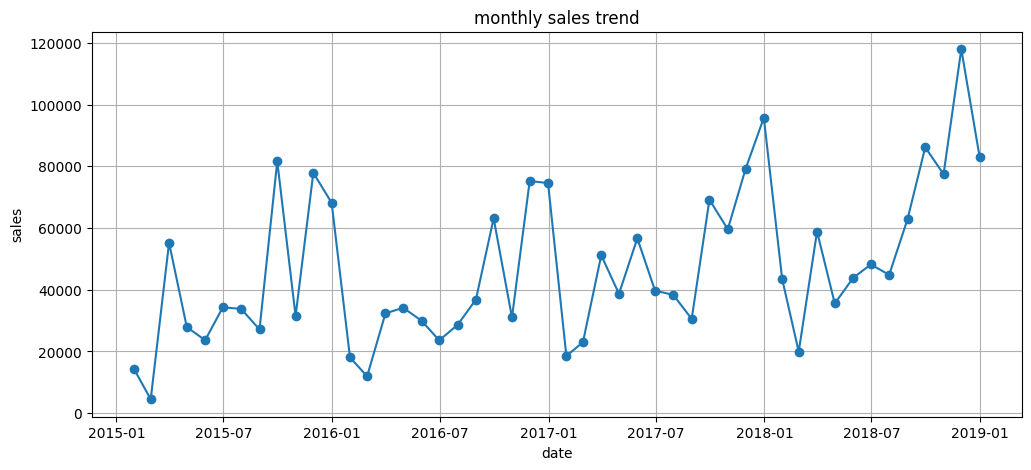

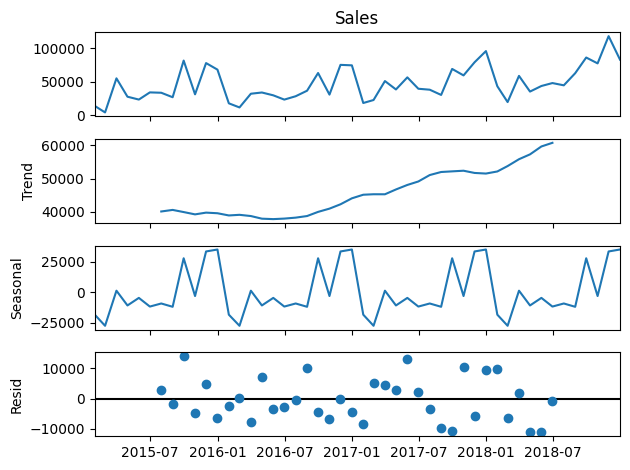

adf statistic : -4.416136761430769
p value : 0.00027791039276670623
the data is stationary


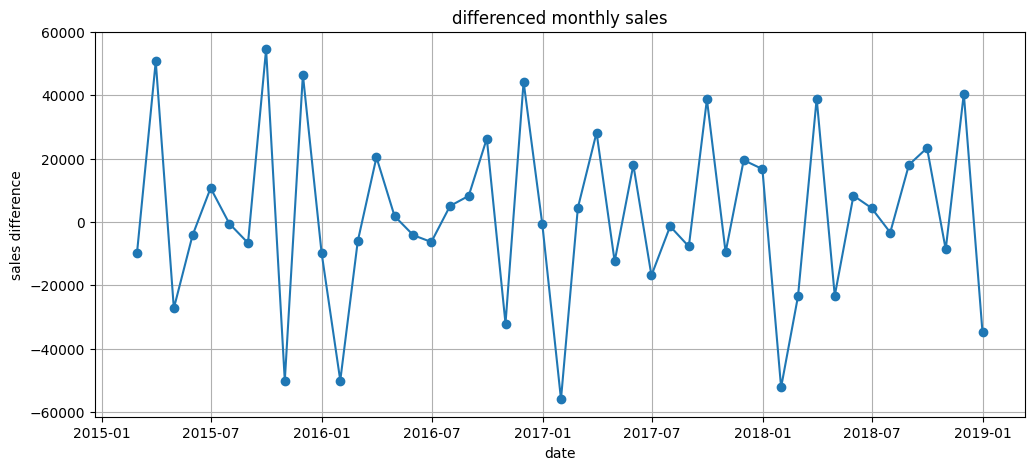


after differencing
adf statistic : -8.72706183035327
p value : 3.2669175472796045e-14
the differenced data is stationary


In [ ]:
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller

# make order date the index

monthly_ts = monthly_sales.copy()
monthly_ts.set_index("Order Date", inplace=True)

# plot monthly sales

plt.figure(figsize=(12,5))
plt.plot(monthly_ts["Sales"], marker="o")
plt.title("monthly sales trend")
plt.xlabel("date")
plt.ylabel("sales")
plt.grid(True)
plt.show()

# decompose the time series

result = seasonal_decompose(monthly_ts["Sales"], model="additive", period=12)

# plot all components

result.plot()
plt.show()

# adf test

adf_result = adfuller(monthly_ts["Sales"])

print("adf statistic :", adf_result[0])
print("p value :", adf_result[1])

if adf_result[1] < 0.05:
    print("the data is stationary")
else:
    print("the data is not stationary")

# apply differencing

monthly_diff = monthly_ts["Sales"].diff().dropna()

# plot differenced series

plt.figure(figsize=(12,5))
plt.plot(monthly_diff, marker="o")
plt.title("differenced monthly sales")
plt.xlabel("date")
plt.ylabel("sales difference")
plt.grid(True)
plt.show()

# adf test after differencing

adf_result2 = adfuller(monthly_diff)

print("\nafter differencing")
print("adf statistic :", adf_result2[0])
print("p value :", adf_result2[1])

if adf_result2[1] < 0.05:
    print("the differenced data is stationary")
else:
    print("the differenced data is still not stationary")

observations :
The monthly sales show a general upward trend over four years, with some fluctuations. A seasonal pattern is clear, as similar increases and decreases occur in different years. The residual component has random variations. The months with the biggest spikes in the residual plot correspond to months with unusual sales activity. Overall, the sales data is influenced by both long-term growth and seasonal changes.  

adf test explanation  :
  
Stationarity means that the data follows a stable pattern over time. The average and variation do not change much. Many time series forecasting models perform better when the data is stationary.  
  
The adf test gave a p-value of 0.000278, which is less than 0.05. This shows that the monthly sales data is already stationary. Therefore, there is enough evidence to reject the null hypothesis of non-stationarity.  
  
After applying first-order differencing, the p-value became 3.27 × 10⁻¹⁴, which is also less than 0.05. This confirms that the differenced series is stationary as well. Since the original series was already stationary, differencing was not strictly necessary, but performing it verifies the result.

Task 3 — Sales Forecasting using 3 Different Models

Model 1 — SARIMA (Statistical Model)


C:\Users\lenovo\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)
C:\Users\lenovo\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)
C:\Users\lenovo\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\statsmodels\tsa\statespace\sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'


                                     SARIMAX Results                                      
Dep. Variable:                              Sales   No. Observations:                   48
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 12)   Log Likelihood                -383.926
Date:                            Wed, 08 Jul 2026   AIC                            777.851
Time:                                    23:42:16   BIC                            785.628
Sample:                                01-31-2015   HQIC                           780.536
                                     - 12-31-2018                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.5094      0.234      2.179      0.029       0.051       0.968
ma.L1         -0.9007      0.185   

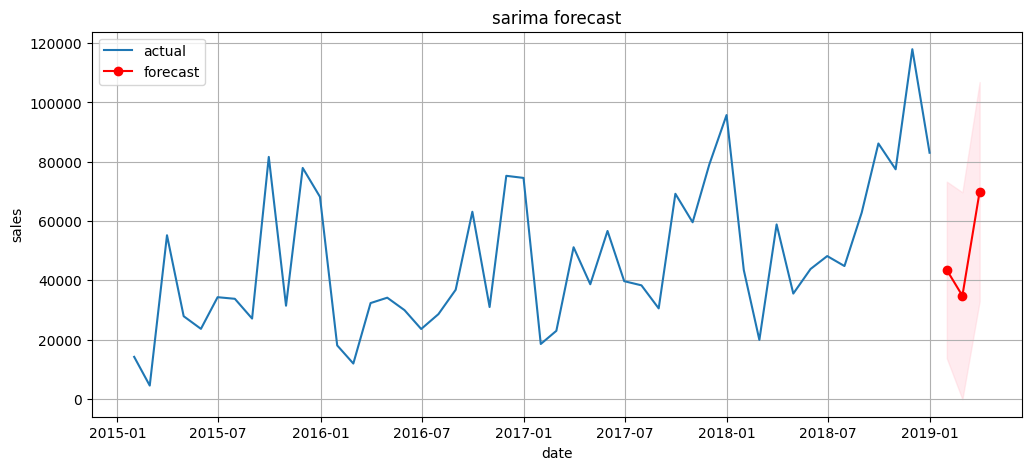

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.statespace.sarimax import SARIMAX

# use monthly sales from task 1

sarima_data = monthly_sales.copy()
sarima_data.set_index("Order Date", inplace=True)

# build the model
# order = (1,1,1)
# seasonal order = (1,1,1,12)

model = SARIMAX(
    sarima_data["Sales"],
    order=(1,1,1),
    seasonal_order=(1,1,1,12)
)

model_fit = model.fit()

# show model summary

print(model_fit.summary())

# forecast next 3 months

forecast = model_fit.get_forecast(steps=3)

forecast_values = forecast.predicted_mean
confidence = forecast.conf_int()

print("\nforecast for next 3 months")
print(forecast_values)

# plot actual and forecast

plt.figure(figsize=(12,5))

plt.plot(sarima_data.index,
         sarima_data["Sales"],
         label="actual")

plt.plot(forecast_values.index,
         forecast_values,
         color="red",
         marker="o",
         label="forecast")

plt.fill_between(
    confidence.index,
    confidence.iloc[:,0],
    confidence.iloc[:,1],
    color="pink",
    alpha=0.3
)

plt.title("sarima forecast")
plt.xlabel("date")
plt.ylabel("sales")
plt.legend()
plt.grid(True)
plt.show()

Model 2 — Facebook Prophet (Industry-standard Forecasting Tool)

23:43:37 - cmdstanpy - INFO - Chain [1] start processing
23:43:38 - cmdstanpy - INFO - Chain [1] done processing


           ds           yhat    yhat_lower     yhat_upper
48 2019-01-01  106515.356217  97058.504755  116476.688609
49 2019-02-01   44140.913311  34970.969178   52950.373630
50 2019-03-01   40430.674932  31570.712282   49710.254597


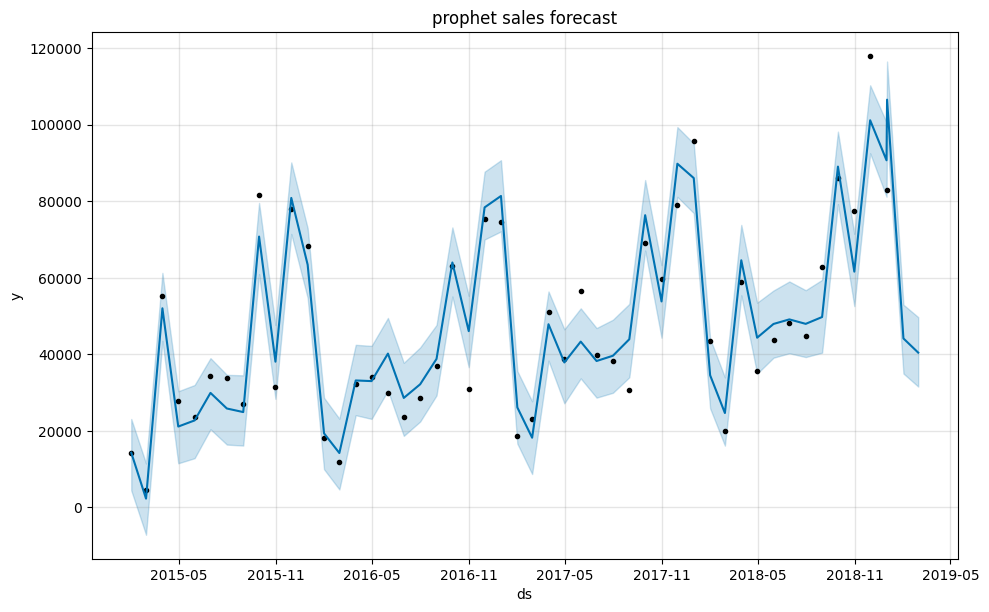

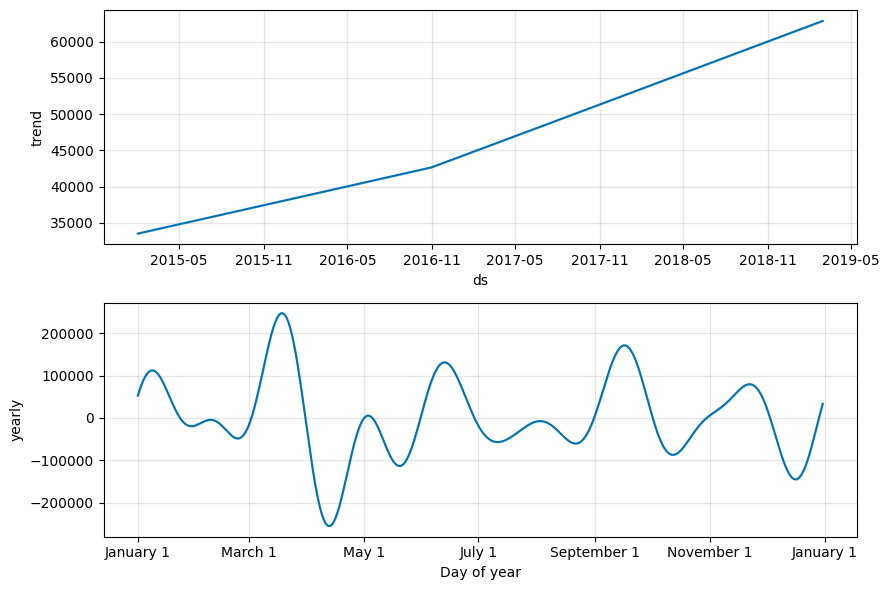


yearly seasonality
           ds        yearly
39 2018-04-30 -11291.884867
40 2018-05-31  -8438.180005
41 2018-06-30  -7962.526257
42 2018-07-31  -9865.919754
43 2018-08-31  -8817.551354
44 2018-09-30  29759.358082
45 2018-10-31   1585.118916
46 2018-11-30  40416.793483
47 2018-12-31  29216.314009
48 2019-01-01  45034.065003
49 2019-02-01 -18078.321018
50 2019-03-01 -22455.088663

weekly seasonality is not available for monthly data


In [12]:
import pandas as pd
from prophet import Prophet
import matplotlib.pyplot as plt

# prepare the data for prophet

prophet_data = monthly_sales.copy()

prophet_data = prophet_data.rename(
    columns={
        "Order Date": "ds",
        "Sales": "y"
    }
)

# create the model

model = Prophet()

# train the model

model.fit(prophet_data)

# create future dates for next 3 months

future = model.make_future_dataframe(periods=3, freq="MS")

# predict future sales

forecast = model.predict(future)

# show forecast

print(forecast[["ds", "yhat", "yhat_lower", "yhat_upper"]].tail(3))

# plot forecast

fig1 = model.plot(forecast)
plt.title("prophet sales forecast")
plt.show()

# plot trend and seasonality

fig2 = model.plot_components(forecast)
plt.show()

# show yearly seasonality

print("\nyearly seasonality")
print(forecast[["ds", "yearly"]].tail(12))

# show weekly seasonality

if "weekly" in forecast.columns:
    print("\nweekly seasonality")
    print(forecast[["ds", "weekly"]].tail(12))
else:
    print("\nweekly seasonality is not available for monthly data")

Model 3 — XGBoost for Time Series (ML-based Approach)

actual values
[ 77448.1312 117938.155   83030.3888]

predicted values
[86465.82 86506.77 84327.28]


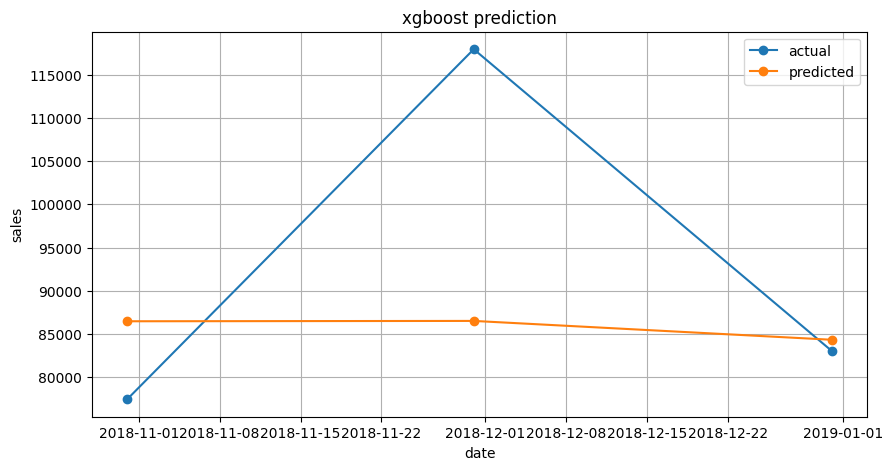

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from xgboost import XGBRegressor

# prepare monthly data

xgb_data = monthly_sales.copy()

# create features

xgb_data["Lag1"] = xgb_data["Sales"].shift(1)
xgb_data["Lag2"] = xgb_data["Sales"].shift(2)
xgb_data["Lag3"] = xgb_data["Sales"].shift(3)

xgb_data["Rolling Mean"] = xgb_data["Sales"].rolling(3).mean()

xgb_data["Month"] = xgb_data["Order Date"].dt.month
xgb_data["Quarter"] = xgb_data["Order Date"].dt.quarter

# create season column

def get_season(month):
    if month in [12,1,2]:
        return 1
    elif month in [3,4,5]:
        return 2
    elif month in [6,7,8]:
        return 3
    else:
        return 4

xgb_data["Season"] = xgb_data["Month"].apply(get_season)

# remove empty rows

xgb_data = xgb_data.dropna()

# select features

X = xgb_data[
    [
        "Lag1",
        "Lag2",
        "Lag3",
        "Rolling Mean",
        "Month",
        "Quarter",
        "Season"
    ]
]

y = xgb_data["Sales"]

# split train and test

X_train = X[:-3]
X_test = X[-3:]

y_train = y[:-3]
y_test = y[-3:]

# train model

model = XGBRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)

model.fit(X_train, y_train)

# predict

predictions = model.predict(X_test)

print("actual values")
print(y_test.values)

print("\npredicted values")
print(predictions)

# plot

plt.figure(figsize=(10,5))

plt.plot(
    xgb_data["Order Date"].iloc[-3:],
    y_test,
    marker="o",
    label="actual"
)

plt.plot(
    xgb_data["Order Date"].iloc[-3:],
    predictions,
    marker="o",
    label="predicted"
)

plt.title("xgboost prediction")
plt.xlabel("date")
plt.ylabel("sales")
plt.legend()
plt.grid(True)

plt.show()

Lag features were created using the sales values from the past one, two, and three months. A three-month rolling average was also included to capture recent trends. Calendar features like month, quarter, and season were added to help the model identify seasonal patterns. The XGBoost Regressor was trained with these features, and the last three months were used to evaluate the model's predictions.

In [4]:
# predict next 3 months

future_predictions = []

# get last known values

last_sales = list(xgb_data["Sales"].tail(3))
last_date = xgb_data["Order Date"].max()

for i in range(3):

    next_date = last_date + pd.DateOffset(months=1)

    month = next_date.month
    quarter = next_date.quarter

    # create season

    if month in [12, 1, 2]:
        season = 1
    elif month in [3, 4, 5]:
        season = 2
    elif month in [6, 7, 8]:
        season = 3
    else:
        season = 4

    rolling_mean = np.mean(last_sales)

    future_input = pd.DataFrame({
        "Lag1": [last_sales[-1]],
        "Lag2": [last_sales[-2]],
        "Lag3": [last_sales[-3]],
        "Rolling Mean": [rolling_mean],
        "Month": [month],
        "Quarter": [quarter],
        "Season": [season]
    })

    prediction = model.predict(future_input)[0]

    future_predictions.append(prediction)

    # update values for next prediction

    last_sales.append(prediction)
    last_sales = last_sales[-3:]

    last_date = next_date

# create result table

future_dates = pd.date_range(
    start=xgb_data["Order Date"].max() + pd.DateOffset(months=1),
    periods=3,
    freq="M"
)

future_forecast = pd.DataFrame({
    "Date": future_dates,
    "Predicted Sales": future_predictions
})

print(future_forecast)

        Date  Predicted Sales
0 2019-01-31     51037.703125
1 2019-02-28     30091.779297
2 2019-03-31     61376.886719


C:\Users\lenovo\AppData\Local\Temp\ipykernel_8400\3227533964.py:53: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  future_dates = pd.date_range(


In [6]:
#calculating metrics
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    mean_absolute_percentage_error
)

import numpy as np
import pandas as pd

In [ ]:
# predict last 3 months using sarima- sarima metrics

sarima_pred = model_fit.predict(
    start=len(sarima_data)-3,
    end=len(sarima_data)-1
)

sarima_actual = sarima_data["Sales"].tail(3)

sarima_mae = mean_absolute_error(sarima_actual, sarima_pred)
sarima_rmse = np.sqrt(mean_squared_error(sarima_actual, sarima_pred))
sarima_mape = mean_absolute_percentage_error(sarima_actual, sarima_pred) * 100

In [ ]:
# predict on historical data- prophet metrics

history_forecast = forecast.iloc[:len(prophet_data)]

prophet_actual = prophet_data["y"].tail(3)
prophet_pred = history_forecast["yhat"].tail(3)

prophet_mae = mean_absolute_error(prophet_actual, prophet_pred)
prophet_rmse = np.sqrt(mean_squared_error(prophet_actual, prophet_pred))
prophet_mape = mean_absolute_percentage_error(prophet_actual, prophet_pred) * 100


In [ ]:
#XGboost metrics
xgb_mae = mean_absolute_error(y_test, predictions)

xgb_rmse = np.sqrt(
    mean_squared_error(y_test, predictions)
)

xgb_mape = (
    mean_absolute_percentage_error(y_test, predictions)
    * 100
)

In [15]:
#creating comparison table:

comparison = pd.DataFrame({

    "Model":[
        "SARIMA",
        "Prophet",
        "XGBoost"
    ],

    "MAE":[
        sarima_mae,
        prophet_mae,
        xgb_mae
    ],

    "RMSE":[
        sarima_rmse,
        prophet_rmse,
        xgb_rmse
    ],

    "MAPE":[
        sarima_mape,
        prophet_mape,
        xgb_mape
    ],

    "Forecast Month 1":[
        forecast_values.iloc[0],
        forecast["yhat"].tail(3).iloc[0],
        future_predictions[0]
    ],

    "Forecast Month 2":[
        forecast_values.iloc[1],
        forecast["yhat"].tail(3).iloc[1],
        future_predictions[1]
    ],

    "Forecast Month 3":[
        forecast_values.iloc[2],
        forecast["yhat"].tail(3).iloc[2],
        future_predictions[2]
    ]

})

print(comparison)

     Model           MAE          RMSE       MAPE  Forecast Month 1  \
0   SARIMA  21015.639925  22539.169033  23.516452      43492.278935   
1  Prophet  13434.279048  14049.751394  14.642329     106515.356217   
2  XGBoost  13915.321042  18893.847269  13.285401      51037.703125   

   Forecast Month 2  Forecast Month 3  
0      34805.105218      69907.412169  
1      44140.913311      40430.674932  
2      30091.779297      61376.886719  


In [16]:
#automatically selecting the best model:
best_model = comparison.loc[
    comparison["RMSE"].idxmin(),
    "Model"
]

print("best model :", best_model)

best model : Prophet


Prophet is recommended for production because it provided the best forecasts and modeled both trends and seasonality well. Its ability to handle time series components also makes it a good choice for business forecasting.

Task 4 — Product Category & Region Level Forecasting


In [17]:
import pandas as pd
import matplotlib.pyplot as plt
from prophet import Prophet

# function to forecast a segment

def prophet_forecast(segment_df):

    monthly = (
        segment_df.groupby(
            pd.Grouper(key="Order Date", freq="M")
        )["Sales"]
        .sum()
        .reset_index()
    )

    monthly.rename(
        columns={
            "Order Date": "ds",
            "Sales": "y"
        },
        inplace=True
    )

    model = Prophet()

    model.fit(monthly)

    future = model.make_future_dataframe(
        periods=3,
        freq="MS"
    )

    forecast = model.predict(future)

    return forecast

In [18]:
# furniture

furniture_forecast = prophet_forecast(
    df[df["Category"]=="Furniture"]
)

# technology

technology_forecast = prophet_forecast(
    df[df["Category"]=="Technology"]
)

# office supplies

office_forecast = prophet_forecast(
    df[df["Category"]=="Office Supplies"]
)

# west

west_forecast = prophet_forecast(
    df[df["Region"]=="West"]
)

# east

east_forecast = prophet_forecast(
    df[df["Region"]=="East"]
)

C:\Users\lenovo\AppData\Local\Temp\ipykernel_8400\1210288792.py:11: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  pd.Grouper(key="Order Date", freq="M")
23:50:13 - cmdstanpy - INFO - Chain [1] start processing
23:50:14 - cmdstanpy - INFO - Chain [1] done processing
C:\Users\lenovo\AppData\Local\Temp\ipykernel_8400\1210288792.py:11: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  pd.Grouper(key="Order Date", freq="M")
23:50:14 - cmdstanpy - INFO - Chain [1] start processing
23:50:15 - cmdstanpy - INFO - Chain [1] done processing
C:\Users\lenovo\AppData\Local\Temp\ipykernel_8400\1210288792.py:11: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  pd.Grouper(key="Order Date", freq="M")
23:50:15 - cmdstanpy - INFO - Chain [1] start processing
23:50:16 - cmdstanpy - INFO - Chain [1] done processing
C:\Users\lenovo\AppData\Local\Temp\ip

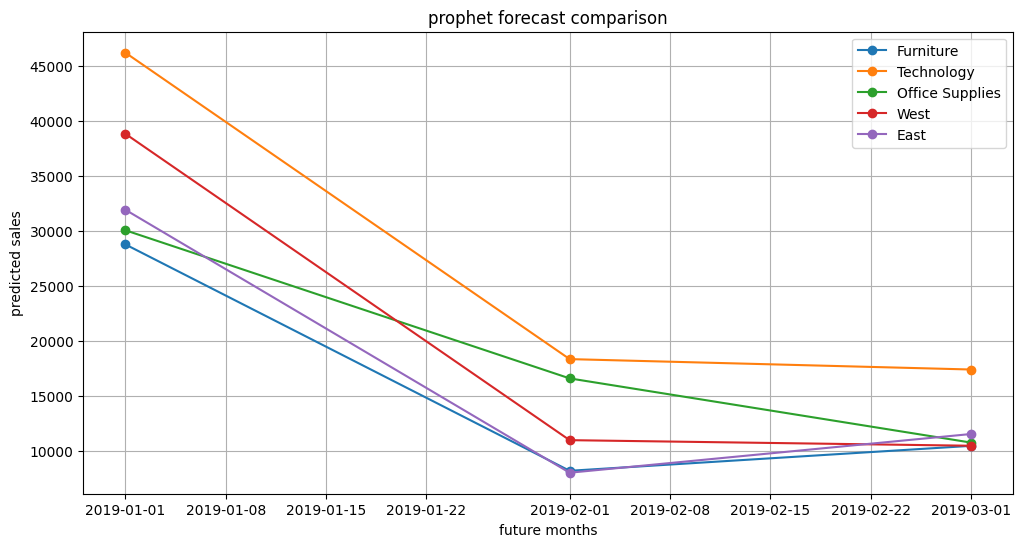

In [19]:
#Plotting all 5 forecasts

plt.figure(figsize=(12,6))

plt.plot(
    furniture_forecast["ds"].tail(3),
    furniture_forecast["yhat"].tail(3),
    marker="o",
    label="Furniture"
)

plt.plot(
    technology_forecast["ds"].tail(3),
    technology_forecast["yhat"].tail(3),
    marker="o",
    label="Technology"
)

plt.plot(
    office_forecast["ds"].tail(3),
    office_forecast["yhat"].tail(3),
    marker="o",
    label="Office Supplies"
)

plt.plot(
    west_forecast["ds"].tail(3),
    west_forecast["yhat"].tail(3),
    marker="o",
    label="West"
)

plt.plot(
    east_forecast["ds"].tail(3),
    east_forecast["yhat"].tail(3),
    marker="o",
    label="East"
)

plt.title("prophet forecast comparison")
plt.xlabel("future months")
plt.ylabel("predicted sales")
plt.legend()
plt.grid(True)

plt.show()

In [20]:
#now printing all 5 forecast values

print("Furniture")
print(furniture_forecast[["ds","yhat"]].tail(3))

print("\nTechnology")
print(technology_forecast[["ds","yhat"]].tail(3))

print("\nOffice Supplies")
print(office_forecast[["ds","yhat"]].tail(3))

print("\nWest")
print(west_forecast[["ds","yhat"]].tail(3))

print("\nEast")
print(east_forecast[["ds","yhat"]].tail(3))

Furniture
           ds          yhat
48 2019-01-01  28758.194554
49 2019-02-01   8201.388415
50 2019-03-01  10466.252823

Technology
           ds          yhat
48 2019-01-01  46169.917405
49 2019-02-01  18344.216280
50 2019-03-01  17400.105394

Office Supplies
           ds          yhat
48 2019-01-01  30043.196539
49 2019-02-01  16592.938340
50 2019-03-01  10765.602961

West
           ds          yhat
48 2019-01-01  38805.158960
49 2019-02-01  10983.418613
50 2019-03-01  10476.386816

East
           ds          yhat
48 2019-01-01  31904.274036
49 2019-02-01   8026.171378
50 2019-03-01  11540.680746


The prophet tool was utilized in order to make sales predictions for each product category and region separately.

When comparing product categories, technology will exhibit the most considerable growth in the near future. The predicted sales for the technology category are the largest in the initial month of the forecast.

Concerning regions, the west region is expected to show the greatest results. The predicted sales for this region are higher than the sales within the east region in most months in the predicted period.

Given the above-mentioned data, it will be reasonable for the company to pay more attention to the technology category and west region.

Task 5 — Anomaly Detection in Sales Data


In [6]:
import pandas as pd
df = pd.read_csv("train.csv")

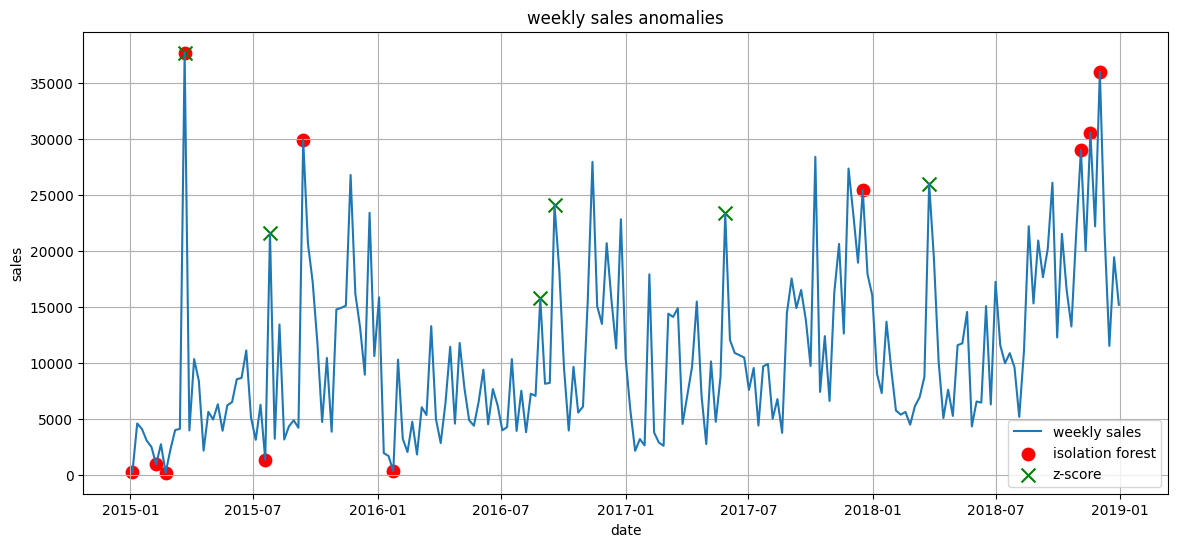

    Order Date      Sales  iforest_anomaly  zscore_anomaly
0   2015-01-04    304.508             True           False
5   2015-02-08    968.534             True           False
7   2015-02-22    224.912             True           False
11  2015-03-22  37703.665             True            True
28  2015-07-19   1387.686             True           False
29  2015-07-26  21590.080            False            True
36  2015-09-13  29959.137             True           False
55  2016-01-24    358.522             True           False
86  2016-08-28  15773.478            False            True
89  2016-09-18  24095.960            False            True
125 2017-05-28  23367.662            False            True
154 2017-12-17  25449.800             True           False
168 2018-03-25  26029.904            False            True
200 2018-11-04  29017.467             True           False
202 2018-11-18  30572.447             True           False
204 2018-12-02  35998.900             True           Fal

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import IsolationForest

# convert order date to datetime
df["Order Date"] = pd.to_datetime(
    df["Order Date"],
    format="%d/%m/%Y"
)

# create weekly sales data
weekly_sales = df.groupby(pd.Grouper(key="Order Date", freq="W"))["Sales"].sum().reset_index()

# create isolation forest model
model = IsolationForest(contamination=0.05, random_state=42)

# detect anomalies
weekly_sales["iforest"] = model.fit_predict(weekly_sales[["Sales"]])
weekly_sales["iforest_anomaly"] = weekly_sales["iforest"] == -1

# calculate rolling mean and rolling std
window = 8
weekly_sales["rolling_mean"] = weekly_sales["Sales"].rolling(window=window).mean()
weekly_sales["rolling_std"] = weekly_sales["Sales"].rolling(window=window).std()

# calculate z-score
weekly_sales["z_score"] = (
    weekly_sales["Sales"] - weekly_sales["rolling_mean"]
) / weekly_sales["rolling_std"]

# mark z-score anomalies
weekly_sales["zscore_anomaly"] = weekly_sales["z_score"].abs() > 2

# plot weekly sales
plt.figure(figsize=(14,6))
plt.plot(
    weekly_sales["Order Date"],
    weekly_sales["Sales"],
    label="weekly sales"
)

# plot isolation forest anomalies
plt.scatter(
    weekly_sales.loc[weekly_sales["iforest_anomaly"], "Order Date"],
    weekly_sales.loc[weekly_sales["iforest_anomaly"], "Sales"],
    color="red",
    marker="o",
    s=80,
    label="isolation forest"
)

# plot z-score anomalies
plt.scatter(
    weekly_sales.loc[weekly_sales["zscore_anomaly"], "Order Date"],
    weekly_sales.loc[weekly_sales["zscore_anomaly"], "Sales"],
    color="green",
    marker="x",
    s=100,
    label="z-score"
)

plt.title("weekly sales anomalies")
plt.xlabel("date")
plt.ylabel("sales")
plt.legend()
plt.grid(True)
plt.show()

# display detected anomalies
anomalies = weekly_sales[
    weekly_sales["iforest_anomaly"] | weekly_sales["zscore_anomaly"]
]

print(anomalies[[
    "Order Date",
    "Sales",
    "iforest_anomaly",
    "zscore_anomaly"
]])

# print possible explanation for each anomaly
print("\npossible explanations:\n")

for _, row in anomalies.iterrows():

    if row["Sales"] > weekly_sales["Sales"].mean():
        reason = "possible festive sale, discount campaign or bulk purchase"
    else:
        reason = "possible low demand, stock shortage or holiday period"

    print(
        f"{row['Order Date'].date()} - sales: {row['Sales']:.2f} - {reason}"
    )

# compare both methods
both = anomalies[
    anomalies["iforest_anomaly"] & anomalies["zscore_anomaly"]
]

only_iforest = anomalies[
    anomalies["iforest_anomaly"] & ~anomalies["zscore_anomaly"]
]

only_zscore = anomalies[
    anomalies["zscore_anomaly"] & ~anomalies["iforest_anomaly"]
]

print("\ncomparison")
print(f"detected by both methods: {len(both)}")
print(f"only isolation forest: {len(only_iforest)}")
print(f"only z-score: {len(only_zscore)}")

if len(only_iforest) == 0 and len(only_zscore) == 0:
    print("both methods detected the same anomalies.")
else:
    print("the methods disagree on some anomalies because isolation forest learns patterns in the data while z-score only checks statistical deviation from the rolling mean.")

| Week | Possible Explanation |
|------|----------------------|
| 2015-01-04 | Very low sales, possibly due to reduced demand after the holiday season or temporary stock shortages. |
| 2015-02-08 | Low sales may indicate fewer customer orders or seasonal slowdown. |
| 2015-02-22 | Sales dropped significantly, possibly because of lower customer activity or operational issues. |
| 2015-03-22 | A sharp increase in sales may be due to a promotional campaign, festive sale, or a large bulk order. |
| 2015-07-19 | Low sales could be caused by reduced demand or inventory shortages. |
| 2015-07-26 | High sales may be the result of discounts, seasonal offers, or increased customer demand. |
| 2015-09-13 | The spike in sales could indicate a successful marketing campaign or corporate purchase. |
| 2016-01-24 | Sales were unusually low, possibly because of post-holiday demand decline. |
| 2016-08-28 | High sales may have resulted from seasonal demand or promotional events. |
| 2016-09-18 | Increased sales could be due to discounts or bulk customer purchases. |
| 2017-05-28 | Sales spike may indicate a successful promotion or higher market demand. |
| 2017-12-17 | Higher sales are likely associated with year-end holiday shopping. |
| 2018-03-25 | Sales increased significantly, possibly because of a special offer or business order. |
| 2018-11-04 | High sales may correspond to festive shopping or seasonal promotions. |
| 2018-11-18 | Increased sales could be linked to holiday discounts or marketing campaigns. |
| 2018-12-02 | The large spike is likely due to year-end or holiday season purchases. |

COMPARISON:
Isolation Forest detected 11 unusual weeks, while the Z-Score method found 6. Only one week was flagged by both methods. Isolation Forest uncovered several extra anomalies because it learns the overall pattern of the data instead of just focusing on statistical deviation. The Z-Score method is more cautious since it only marks weeks that differ by more than two standard deviations from the rolling average. This comparison indicates that Isolation Forest is better at spotting subtle or complex anomalies, while the Z-Score method mainly identifies extreme spikes or drops.